# Power consumption

## Matrix mutliplication

In [17]:
FOLDER = "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/linear_slurm_2025-07-11-15-47-13"
import os 
import pandas as pd

results = []
for csv in os.listdir(FOLDER):
    if csv.endswith(".csv") and 'power' in csv:
        b = int(csv.split("_b")[1].split("_")[0])
        h = int(csv.split("_h")[1].split("_")[0])
        d = int(csv.split("_d")[1].split("_")[0])
        s = int(csv.split("_s")[1].split(".")[0])
        power_df = pd.read_csv(os.path.join(FOLDER, csv))
        max_power = power_df['power_w'].max()
        mean_power = power_df['power_w'].mean()
        min_power = power_df['power_w'].min()
        last_power = power_df['power_w'].iloc[-1]
        results.append({
            'name': csv,
            'batch_size': b,
            'hidden_size': h,
            'dim': d,
            'seq_len': s,
            'max_power': max_power,
            'mean_power': mean_power,
            'min_power': min_power,
            'last_power': last_power
        })
df = pd.DataFrame(results)
df


,name,batch_size,hidden_size,dim,seq_len,max_power,mean_power,min_power,last_power
0,exp1_power_linear_b1_h4096_d11008_s1515.csv,1,4096,11008,1515,161.001,148.430865,130.095,147.055
1,exp1_power_linear_b1_h4096_d11008_s2313.csv,1,4096,11008,2313,181.238,163.425268,133.198,169.416
2,exp1_power_linear_b1_h4096_d11008_s814.csv,1,4096,11008,814,144.651,138.509010,124.968,144.228
3,exp1_power_linear_b1_h4096_d11008_s3800.csv,1,4096,11008,3800,611.321,185.340417,141.424,192.772
4,exp1_power_linear_b1_h4096_d11008_s1075.csv,1,4096,11008,1075,148.919,141.739375,120.854,148.341
...,...,...,...,...,...,...,...,...,...
3950,exp1_power_linear_b1_h4096_d11008_s2430.csv,1,4096,11008,2430,183.056,165.330895,122.351,172.256
3951,exp1_power_linear_b1_h4096_d11008_s3547.csv,1,4096,11008,3547,209.507,183.098528,140.649,190.686
3952,exp1_power_linear_b1_h4096_d11008_s1657.csv,1,4096,11008,1657,160.022,149.589030,122.152,152.631
3953,exp1_power_linear_b1_h4096_d11008_s1395.csv,1,4096,11008,1395,154.907,145.905276,121.862,147.263


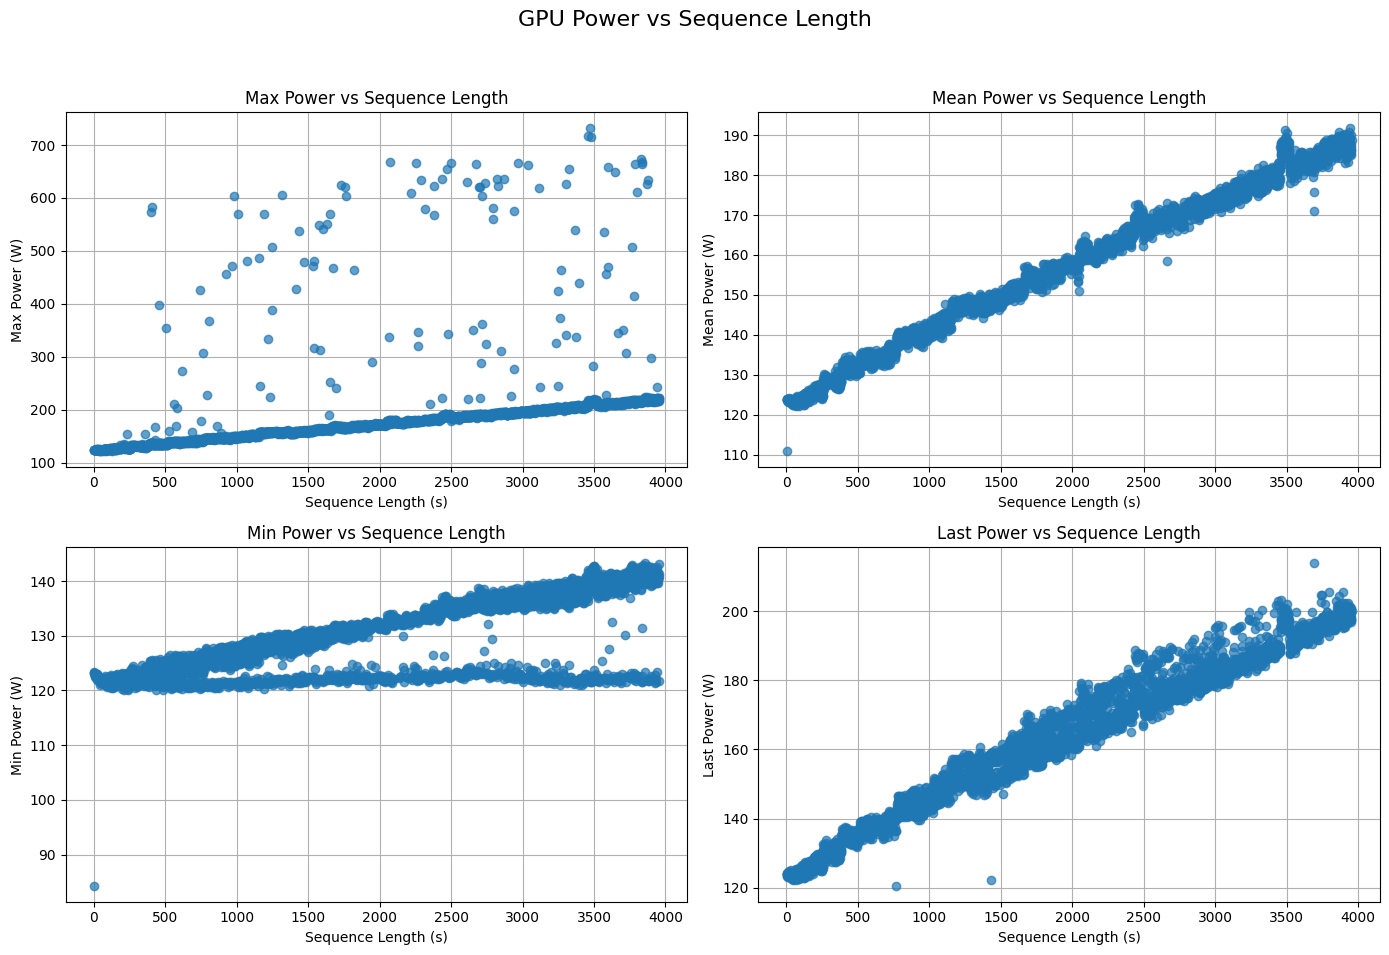

In [18]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GPU Power vs Sequence Length", fontsize=16)

# Subplot 1: max_power
axs[0, 0].plot(df['seq_len'], df['max_power'], 'o', alpha=0.7)
axs[0, 0].set_title("Max Power vs Sequence Length")
axs[0, 0].set_xlabel("Sequence Length (s)")
axs[0, 0].set_ylabel("Max Power (W)")

# Subplot 2: mean_power
axs[0, 1].plot(df['seq_len'], df['mean_power'], 'o', alpha=0.7)
axs[0, 1].set_title("Mean Power vs Sequence Length")
axs[0, 1].set_xlabel("Sequence Length (s)")
axs[0, 1].set_ylabel("Mean Power (W)")

# Subplot 3: min_power
axs[1, 0].plot(df['seq_len'], df['min_power'], 'o', alpha=0.7)
axs[1, 0].set_title("Min Power vs Sequence Length")
axs[1, 0].set_xlabel("Sequence Length (s)")
axs[1, 0].set_ylabel("Min Power (W)")

# Subplot 4: last_power
axs[1, 1].plot(df['seq_len'], df['last_power'], 'o', alpha=0.7)
axs[1, 1].set_title("Last Power vs Sequence Length")
axs[1, 1].set_xlabel("Sequence Length (s)")
axs[1, 1].set_ylabel("Last Power (W)")

for ax in axs.flat:
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## LLM

In [11]:
FOLDERS = ["/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_2025-07-11-16-17-43", # no compile input variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_2025-07-11-16-18-52", # compile input variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_batch_2025-07-11-16-25-21", # no compile batch variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8BC_batch_2025-07-11-16-25-12", # compile batch variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8B_output_2025-07-11-16-23-12", # no compile output variation
           "/fsx/jdelavande/benchlab/microbench/data/benchmark_results/llama8BC_output_2025-07-11-16-23-32", # compile output variation
           ]
compile = [True, False, True, False, True, False] # compile input, batch and output variations
import os 
import pandas as pd

results = []
for folder, comp in zip(FOLDERS, compile):
    for csv in os.listdir(folder):
        if csv.endswith(".csv") and 'power' in csv:
            b = int(csv.split("_b")[1].split("_")[0])
            g = int(csv.split("_g")[1].split("_")[0])
            s = int(csv.split("_s")[1].split("_")[0])
            phase = csv.split("trace_")[1].split("_")[0]
            power_df = pd.read_csv(os.path.join(folder, csv))
            max_power = power_df['power_w'].max()
            mean_power = power_df['power_w'].mean()
            min_power = power_df['power_w'].min()
            last_power = power_df['power_w'].iloc[-1]
            results.append({
                'name': csv,
                'phase': phase,
                'compile': comp,
                'batch_size': b,
                'output_length': g,
                'input_length': s,
                'max_power': max_power,
                'mean_power': mean_power,
                'min_power': min_power,
                'last_power': last_power
            })
df_llm = pd.DataFrame(results)
df_llm


,name,phase,compile,batch_size,output_length,input_length,max_power,mean_power,min_power,last_power
0,power_trace_decode_b1_s5_g100_2025-07-11-17-00...,decode,True,1,100,5,326.932,273.132582,132.551,215.193
1,power_trace_decode_b1_s1_g10_2025-07-11-16-18-...,decode,True,1,10,1,283.064,240.452547,175.246,215.628
2,power_trace_prefill_b1_s4_g10_2025-07-11-16-48...,prefill,True,1,10,4,221.933,193.165963,139.337,214.888
3,power_trace_decode_b1_s2_g100_2025-07-11-16-26...,decode,True,1,100,2,379.044,275.196945,173.994,191.611
4,power_trace_decode_b1_s1_g1000_2025-07-11-16-2...,decode,True,1,1000,1,426.581,285.360648,171.151,226.249
...,...,...,...,...,...,...,...,...,...,...
500,power_trace_prefill_b1_s1_g52_2025-07-11-16-37...,prefill,False,1,52,1,192.561,158.995787,129.223,190.837
501,power_trace_prefill_b1_s1_g9_2025-07-11-16-24-...,prefill,False,1,9,1,197.143,168.457664,125.603,193.904
502,power_trace_decode_b1_s1_g83_2025-07-11-16-58-...,decode,False,1,83,1,393.910,257.871002,188.928,201.937
503,power_trace_decode_b1_s1_g64_2025-07-11-16-45-...,decode,False,1,64,1,408.957,254.114098,119.809,210.375


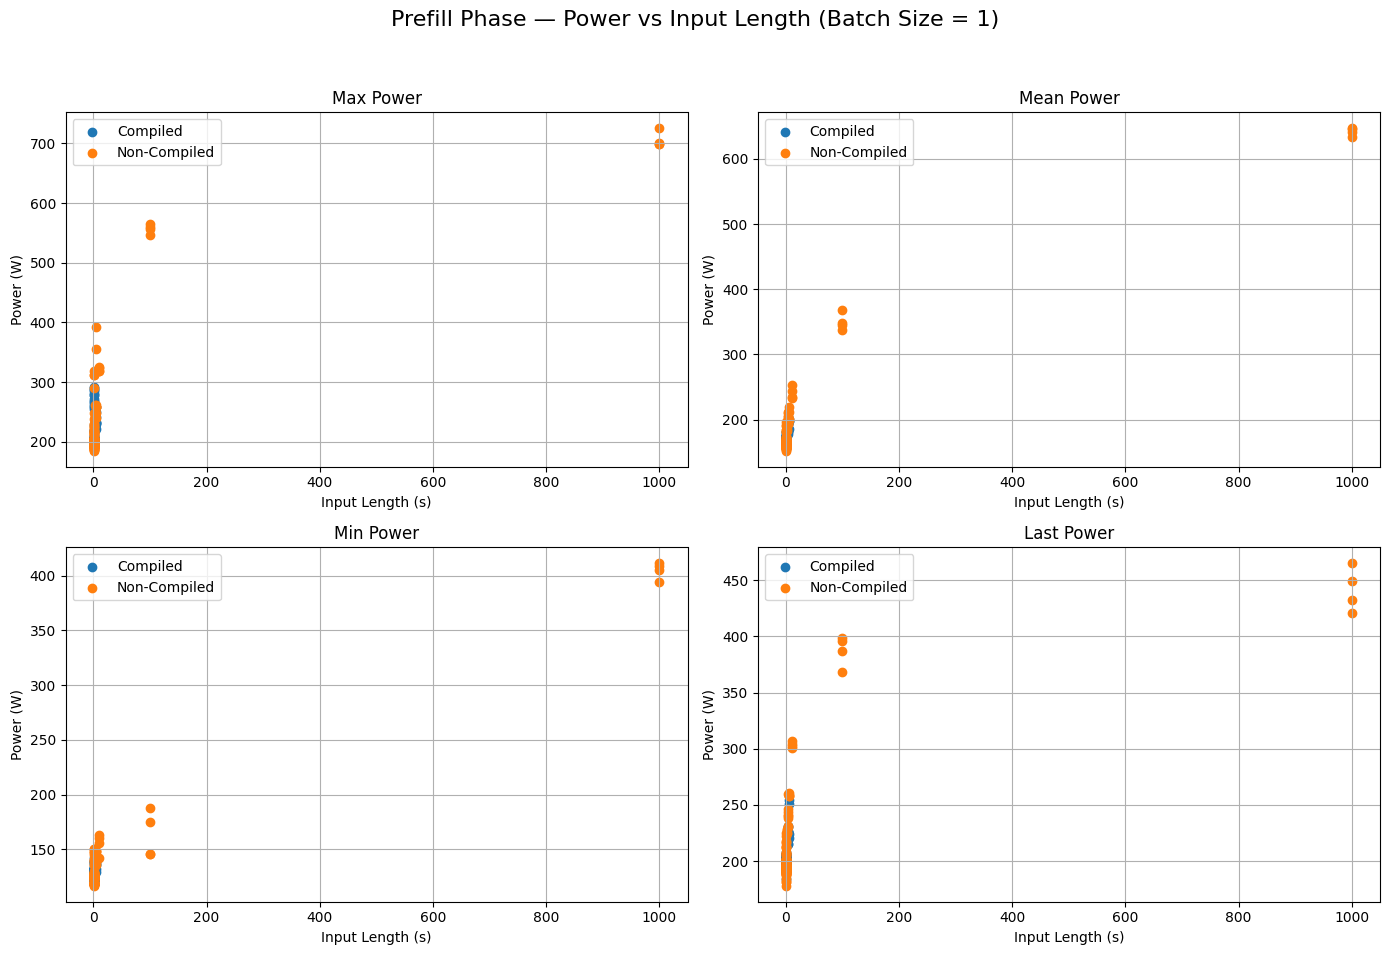

In [14]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = prefill, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "prefill") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Prefill Phase — Power vs Input Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["input_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Input Length (s)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


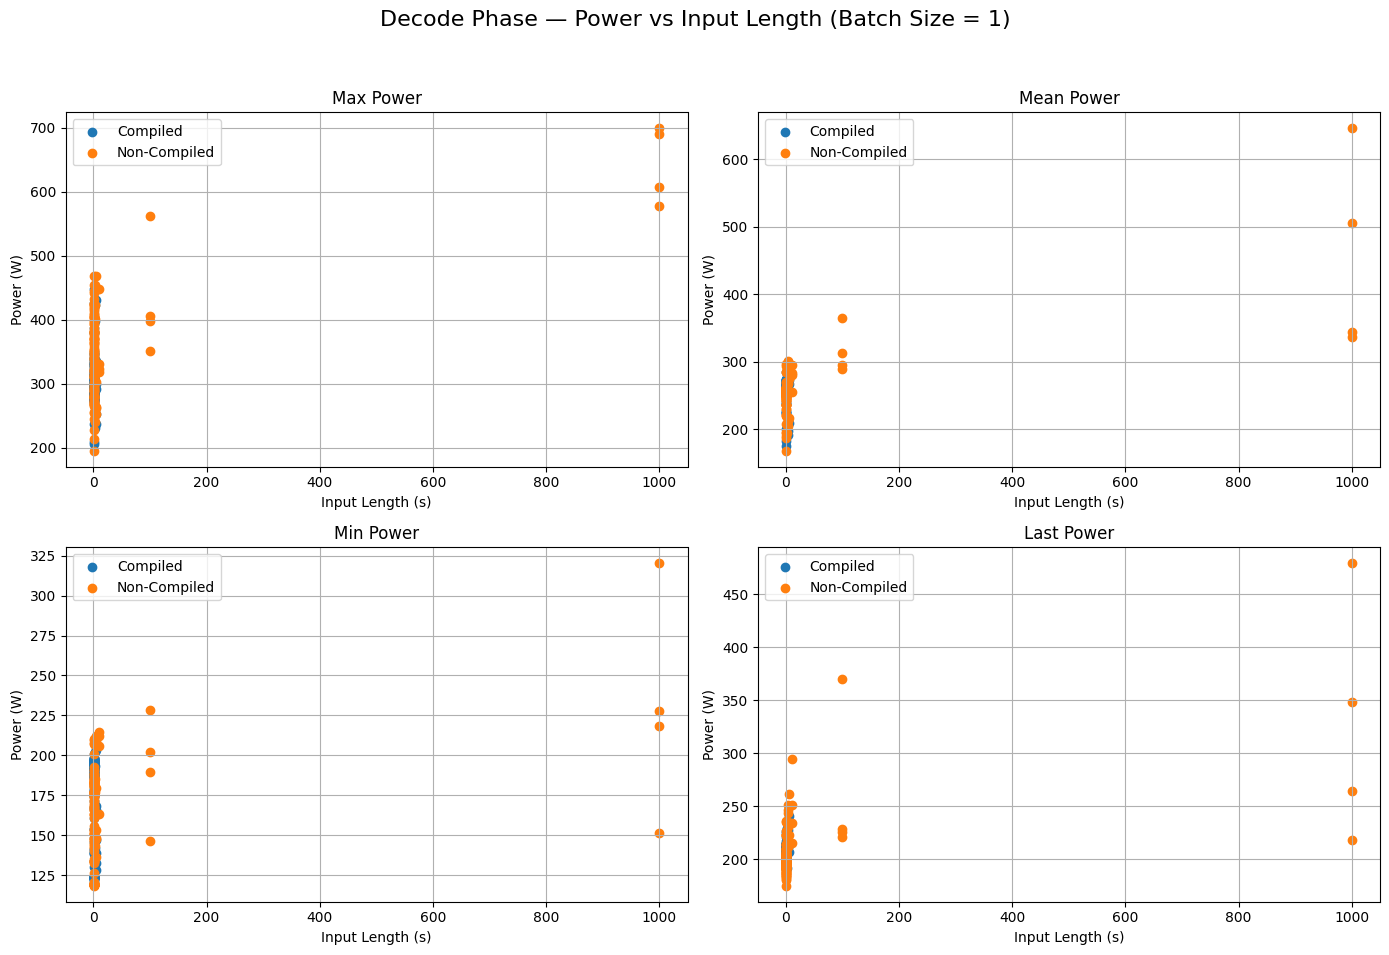

In [15]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = decode, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "decode") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Decode Phase — Power vs Input Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["input_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Input Length (s)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


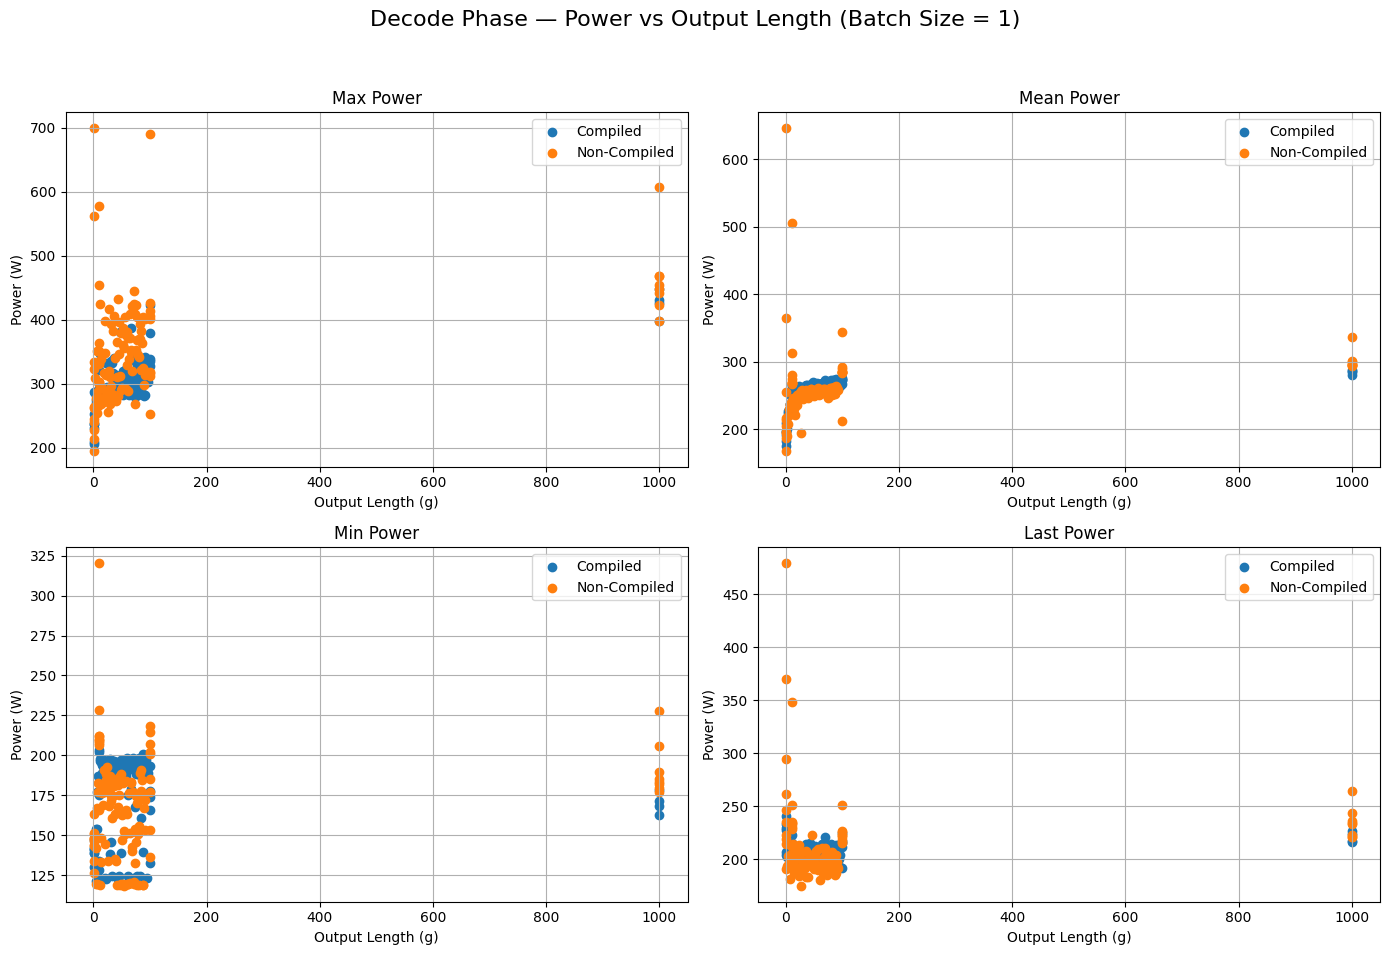

In [16]:
import matplotlib.pyplot as plt

# Filtrage des données : phase = decode, batch_size = 1
df_filtered = df_llm[(df_llm["phase"] == "decode") & (df_llm["batch_size"] == 1)]

# Création des 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Decode Phase — Power vs Output Length (Batch Size = 1)", fontsize=16)

# Fonction pour scatter plot
def scatter_power(ax, y_col, title):
    for comp, label in zip([True, False], ["Compiled", "Non-Compiled"]):
        df_sub = df_filtered[df_filtered["compile"] == comp]
        ax.scatter(df_sub["output_length"], df_sub[y_col], label=label)
    ax.set_title(title)
    ax.set_xlabel("Output Length (g)")
    ax.set_ylabel("Power (W)")
    ax.grid(True)
    ax.legend()

# Subplots
scatter_power(axs[0, 0], "max_power", "Max Power")
scatter_power(axs[0, 1], "mean_power", "Mean Power")
scatter_power(axs[1, 0], "min_power", "Min Power")
scatter_power(axs[1, 1], "last_power", "Last Power")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
